# Прогнозирование ВРП субъектов РФ

Оценка прогнозного качества моделей машинного обучения для реального валового регионального продукта (ВРП) 85 субъектов Российской Федерации, 2005–2023 гг.

**Методология:**
- Расширяющееся окно кросс-валидации (`min_train_years=10`, 9 фолдов: 2015–2023)
- Целевая переменная: Δlog(ВРП) — прирост логарифма реального ВРП
- Наивный бенчмарк: среднеисторический темп роста ВРП по обучающей выборке
- Метрики: RMSE, MAE, OOS R² относительно наивного прогноза

**Модели:**
1. `NaiveForecaster` — бенчмарк (средний исторический темп роста)
2. `AR1Forecaster` — AR(1) по регионам
3. `RidgeFEForecaster` — Ridge с региональными фиксированными эффектами (within-transformation)
4. `LGBMForecaster` — LightGBM с Optuna-тюнингом
5. `CatBoostForecaster` — CatBoost с Optuna-тюнингом
6. `GPBoostForecaster` — GPBoost (бустинг + GP случайные эффекты)
7. `EmbMLPForecaster` — MLP с entity-embeddings; запускается отдельно, не входит в основную кросс-валидацию


## 0. Установка и конфигурация

Загрузка конфигурации (`config.yaml`) и импорт всех модулей пайплайна.  
Зависимости: `lightgbm`, `catboost`, `gpboost`, `torch`, `shap`, `optuna`, `pyyaml`, `pyarrow`.

In [1]:
# !pip install -r requirements.txt

In [2]:
from pathlib import Path
import os

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "grp_forecast" and (PROJECT_DIR / "grp_forecast").exists():
    os.chdir(PROJECT_DIR / "grp_forecast")
os.makedirs("figures", exist_ok=True)



In [3]:
import copy
import warnings
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open("config.yaml") as f:
    CONFIG = yaml.safe_load(f)

from features import PanelDataLoader, FeatureBuilder, build_folds
from models import (
    get_all_models,
    EmbMLPForecaster,
    GPBoostForecaster,
    _transform_numeric_preprocessor,
)
from validation import run_cross_validation, aggregate_results, compute_metrics
from tests import (
    run_ablation_study,
    robustness_check_outliers,
    robustness_check_crisis,
    run_shap_analysis,
    error_analysis,
    test_no_leakage,
    test_scaler_fit_on_train_only,
    test_naive_benchmark,
    test_oos_r2_naive_is_zero,
    test_all_regions_covered,
)
from visualization import *

/Users/tigran/python_projects_epta/учеба/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Загрузка и описание данных

Данные загружаются из `make_data/panel_dataset.csv` через `PanelDataLoader`.  
Панель: 85 регионов × 2005–2023 гг. (~1 615 наблюдений, 180+ признаков).  
После загрузки проверяется покрытие регионов (`test_all_regions_covered`) и выводится
статистика пропусков по признакам.

In [4]:
loader = PanelDataLoader(
    raw_dir=CONFIG["data"]["raw_dir"],
    target_col=CONFIG["data"]["target_col"],
)
df = loader.load()
start_year = CONFIG["data"].get("start_year")
end_year = CONFIG["data"].get("end_year")
if start_year is not None:
    df = df[df["year"] >= start_year]
if end_year is not None:
    df = df[df["year"] <= end_year]
df = df.sort_index()
print(
    f"Панель: {df['region_id'].nunique()} регионов, "
    f"годы {df['year'].min()}–{df['year'].max()}, "
    f"строк: {len(df)}"
)

Панель: 85 регионов, годы 2005–2023, строк: 1615


In [5]:
df.head()

region region_id   region_type  year      vrp  vrp_per_capita  \
region_id year                                                                  
адыгея    2005  адыгея    адыгея  agricultural  2005  17029.1         38514.5   
          2006  адыгея    адыгея  agricultural  2006  21132.4         48050.2   
          2007  адыгея    адыгея  agricultural  2007  29085.1         66366.2   
          2008  адыгея    адыгея  agricultural  2008  36134.4         82378.2   
          2009  адыгея    адыгея  agricultural  2009  41511.5         94436.5   

                vrp_idx  population  employed  unemployment_rate  ...  \
region_id year                                                    ...   
адыгея    2005    108.3       441.0     154.0               13.0  ...   
          2006    107.5       438.6     153.3               13.9  ...   
          2007    116.5       437.9     153.2               10.3  ...   
          2008    113.9       439.4     152.8                7.3  ...   
          2009    105.9       439.8     152.8                7.7  ...   

                 retail  avg_wage_nominal  income_nominal  ipi  transfers  \
region_id year                                                              
адыгея    2005  11110.7            5123.0          3893.0  NaN        NaN   
          2006  13089.4            6414.4          4731.0  NaN        NaN   
          2007  16370.9            8056.4          5802.0  NaN        NaN   
          2008  25645.0           10096.9          8047.0  NaN        NaN   
          2009  31445.1           11547.6         10556.0  NaN        NaN   

                budget_invest  employment_rate  real_income      grp_real  \
region_id year                                                              
адыгея    2005            NaN         0.349206  3485.228290   7057.265571   
          2006            NaN         0.349521  4360.368664   7586.560488   
          2007            NaN         0.349852  5212.938005   8838.342969   
          2008            NaN         0.347747  6991.311903  10066.872642   
          2009            NaN         0.347431  9729.032258  10660.818128   

                log_grp_real  
region_id year                
адыгея    2005      8.861813  
          2006      8.934134  
          2007      9.086855  
          2008      9.217005  
          2009      9.274330  

[5 rows x 181 columns]

In [6]:
df.reset_index(drop=True, inplace=True)

In [7]:
missing = df.isnull().mean().sort_values(ascending=False)
display(missing[missing > 0].to_frame("доля пропусков"))
display(df.groupby("year")["log_grp_real"].describe().round(3))
test_all_regions_covered(df, min_regions=CONFIG["data"]["min_regions"])
print("Проверка числа регионов пройдена")

,доля пропусков
budget_invest,1.000000
transfers,1.000000
regional_cpi_yoy_change_lag1,0.684211
mining_output,0.642724
mining,0.642724
...,...
construction,0.011146
freight_transport,0.011146
rd_expenditure,0.011146
transport,0.011146


,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2005,81.0,10.809,1.198,7.984,10.196,10.715,11.469,14.342
2006,81.0,10.897,1.209,8.015,10.314,10.959,11.544,14.426
2007,81.0,10.994,1.208,8.262,10.390,10.997,11.632,14.494
2008,81.0,11.050,1.216,8.243,10.441,11.017,11.681,14.559
2009,81.0,11.005,1.199,8.108,10.362,11.013,11.760,14.412
2010,81.0,11.052,1.216,8.121,10.395,11.014,11.793,14.494
2011,83.0,11.163,1.253,8.190,10.494,11.102,11.872,14.708
2012,83.0,11.196,1.249,8.303,10.552,11.140,11.891,14.673
2013,83.0,11.215,1.250,8.412,10.559,11.194,11.926,14.661


Проверка числа регионов пройдена


## 2. Построение признаков и фолдов

`build_folds` строит 9 расширяющихся окон (2015–2023). В каждом фолде:  
- `FeatureBuilder` обучается **только на тренировочных строках** — утечки данных исключены.
- `RobustScaler` и медианная импутация применяются к трейну, затем к тесту через `transform`.
- Целевая переменная преобразуется в Δlog(ВРП) = log_grp_t − log_grp_{t−1} (`predict_growth=True`).
- Наивный бенчмарк фолда = средний Δlog(ВРП) по обучающей выборке.

Признаки (~181 после фильтрации пропусков):  
- **LAG_BLOCK**: log_grp_lag1, log_grp_lag2, grp_growth_lag1, grp_ma3_lag1, region_trend
- **PRODUCTION/INVESTMENT/LABOUR/BUDGET**: лаги отраслевых и бюджетных показателей
- **MACRO/PRICE**: ключевая ставка, CPI, курс USD/RUB и их производные
- **COLLECTION**: демографические и социальные показатели
- **CATEGORICAL**: one-hot federal_district, region_type
- **SHOCK_BLOCK**: индикаторы кризисных лет (2008–09, 2014–15, 2020, 2022–23)

In [8]:
missing_drop_threshold = CONFIG["validation"].get("missing_drop_threshold", 0.4)
predict_growth = CONFIG["validation"].get("predict_growth", False)
folds = build_folds(
    df,
    min_train_years=CONFIG["validation"]["min_train_years"],
    target_col=CONFIG["data"]["target_col"],
    processed_dir=CONFIG["data"]["processed_dir"],
    missing_drop_threshold=missing_drop_threshold,
    predict_growth=predict_growth,
)
target_label = "Δlog_grp (growth rate)" if predict_growth else "log_grp (level)"
print(f"Создано {len(folds)} fold'ов")
print(f"Целевая переменная: {target_label}")
print(f"Порог удаления признаков по пропускам: {missing_drop_threshold:.0%}")
for fold in folds:
    dropped = fold.get("dropped_missing_features", [])
    print(
        f"Fold {fold['fold']}: train {fold['train_years'][0]}–"
        f"{fold['train_years'][-1]} -> test {fold['test_year']}; "
        f"удалено по пропускам: {len(dropped)}"
    )

missing_drop_summary = pd.DataFrame(
    [
        {
            "fold": fold["fold"],
            "test_year": fold["test_year"],
            "dropped_features": len(fold.get("dropped_missing_features", [])),
            "features": ", ".join(fold.get("dropped_missing_features", [])),
        }
        for fold in folds
    ]
)
display(missing_drop_summary)

Создано 9 fold'ов
Целевая переменная: Δlog_grp (growth rate)
Порог удаления признаков по пропускам: 40%
Fold 1: train 2005–2014 -> test 2015; удалено по пропускам: 10
Fold 2: train 2005–2015 -> test 2016; удалено по пропускам: 10
Fold 3: train 2005–2016 -> test 2017; удалено по пропускам: 10
Fold 4: train 2005–2017 -> test 2018; удалено по пропускам: 10
Fold 5: train 2005–2018 -> test 2019; удалено по пропускам: 10
Fold 6: train 2005–2019 -> test 2020; удалено по пропускам: 10
Fold 7: train 2005–2020 -> test 2021; удалено по пропускам: 10
Fold 8: train 2005–2021 -> test 2022; удалено по пропускам: 10
Fold 9: train 2005–2022 -> test 2023; удалено по пропускам: 10


,fold,test_year,dropped_features,features
0,1,2015,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
1,2,2016,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
2,3,2017,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
3,4,2018,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
4,5,2019,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
5,6,2020,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
6,7,2021,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
7,8,2022,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."
8,9,2023,10,"ipi_lag1, mining_lag1, manufacturing_lag1, tra..."


### Проверки корректности пайплайна

Перед запуском кросс-валидации выполняется набор unit-тестов:

| Тест | Что проверяет |
|------|---------------|
| `test_no_leakage` | Во всех фолдах `max(train_years) < test_year` |
| `test_scaler_fit_on_train_only` | Медиана scaled-признаков по трейну ≈ 0; `scaler.center_` совпадает с train-медианой |
| `test_naive_benchmark` | `NaiveForecaster.predict` возвращает ровно `y_bench` фолда |
| `test_oos_r2_naive_is_zero` | OOS R² наивного прогноза относительно себя = 0 |
| `test_all_regions_covered` | В панели ≥ `min_regions` уникальных регионов |

In [9]:
test_no_leakage(folds)
test_scaler_fit_on_train_only(folds)
test_naive_benchmark(folds)
test_oos_r2_naive_is_zero(folds)
test_all_regions_covered(df, CONFIG["data"]["min_regions"])
print("Все проверки пайплайна пройдены")


Все проверки пайплайна пройдены


## 3. Кросс-валидация всех моделей

Запускается `run_cross_validation` с расширяющимся окном.  
Для `LGBMForecaster`, `CatBoostForecaster` и `GPBoostForecaster` применяется
Optuna-тюнинг (`n_trials` из config) на внутренней валидации (последние 2 года трейна).  
`EmbMLPForecaster` исключается из основного запуска и проверяется отдельным экспериментом при необходимости.  
Результаты агрегируются по фолдам: mean ± std RMSE / MAE / OOS R².

> **OOS R²** = 1 − SSR / SST, где SST = Σ(y − ŷ_naive)².  
> OOS R² > 0 означает, что модель лучше наивного прогноза.


In [10]:
predict_growth = CONFIG["validation"].get("predict_growth", False)

# get_all_models() возвращает полный список согласно config.yaml:
#   Naive, AR1, RidgeFE, LGBM, CatBoost, WeightedEnsemble, GPBoost
#   + EmbMLP, если emb_mlp.enabled=true (управляется конфигом).
# Ансамбль WeightedEnsembleForecaster включён автоматически;
# EmbMLPForecaster запускается отдельно в секции 9 (или здесь, если enabled=true).
models = get_all_models(CONFIG["models"], predict_growth=predict_growth)
print("Модели основного запуска:", [m.name for m in models])

cv_results = run_cross_validation(
    models=models,
    folds=folds,
    tune=True,
    n_trials=CONFIG["tuning"]["n_trials"],
    save_predictions=True,
)

agg = aggregate_results(cv_results)
display(agg.round(4))

Модели основного запуска: ['NaiveForecaster', 'AR1Forecaster', 'RidgeFEForecaster', 'LGBMForecaster', 'CatBoostForecaster', 'Ensemble(CB×0.25+LGB×0.75)', 'GPBoostForecaster', 'EmbMLPForecaster']


EmbMLPForecaster | fold 9: 100%|██████████| 72/72 [32:46<00:00, 27.31s/it, best=CatBoostForecaster fold=4 RMSE=0.0233]                  

Best single fold: CatBoostForecaster | fold=4 | test_year=2018 | RMSE=0.0233 | MAE=0.0162 | OOS_R2=0.2061


,model_name,RMSE_mean,RMSE_std,MAE_mean,MAE_std,OOS_R2_mean,OOS_R2_std
0,Ensemble(CB×0.25+LGB×0.75),0.0382,0.0129,0.0288,0.0113,0.1440,0.3071
1,LGBMForecaster,0.0388,0.0121,0.0295,0.0105,0.1219,0.2629
2,CatBoostForecaster,0.0408,0.0153,0.0311,0.0135,0.0356,0.3884
3,NaiveForecaster,0.0419,0.0117,0.0331,0.0104,0.0000,0.0000
4,AR1Forecaster,0.0487,0.0216,0.0336,0.0120,-0.4036,0.8911
5,EmbMLPForecaster,0.0491,0.0199,0.0378,0.0166,-0.4386,0.9218
6,RidgeFEForecaster,0.0517,0.0261,0.0419,0.0273,-0.6176,1.0868
7,GPBoostForecaster,0.4882,0.5955,0.4285,0.5568,-280.9273,515.5155


In [11]:
# ─── Утилиты пост-CV анализа (секции 11–13) ──────────────────────────────────
# pred_dir и load_all_folds используются в: поиске веса ансамбля (11),
# тесте Дибольда–Мариано (12) и метриках в рублях (13).

pred_dir = Path(CONFIG["data"]["processed_dir"])


def load_all_folds(model_name: str) -> pd.DataFrame:
    """Загружает и объединяет все fold-parquet-файлы для указанной модели."""
    files = sorted(pred_dir.glob(f"predictions_{model_name}_fold*.parquet"))
    if not files:
        raise FileNotFoundError(
            f"Нет parquet-файлов для {model_name!r} в {pred_dir}. "
            "Запустите кросс-валидацию с save_predictions=True."
        )
    return pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)


available = sorted({f.stem.split("_fold")[0].replace("predictions_", "")
                    for f in pred_dir.glob("predictions_*.parquet")})
print(f"pred_dir: {pred_dir}")
print(f"Модели с сохранёнными parquet ({len(available)}): {available}")

pred_dir: data/processed
Модели с сохранёнными parquet (9): ['AR1Forecaster', 'CatBoostForecaster', 'EmbMLPForecaster', 'Ensemble(CB×0.25+LGB×0.75)', 'Ensemble(CB×0.6+LGB×0.4)', 'GPBoostForecaster', 'LGBMForecaster', 'NaiveForecaster', 'RidgeFEForecaster']


## 11. Поиск оптимального веса ансамбля CatBoost + LGBM

Перебираем вес CatBoost $w \in [0, 1]$ с шагом 0.05 по уже сохранённым
parquet-предсказаниям (без переобучения). Для каждого $w$ вычисляем
pooled RMSE по всем 9 фолдам и выбираем оптимальный вес.  
После этого добавляем `WeightedEnsembleForecaster` в CV-пайплайн и
сравниваем с одиночными моделями.


Оптимальный вес CatBoost: w = 0.25
  Ensemble RMSE (pooled) = 0.0401
  CatBoost RMSE  (w=1.0) = 0.0433
  LGBM RMSE      (w=0.0) = 0.0405


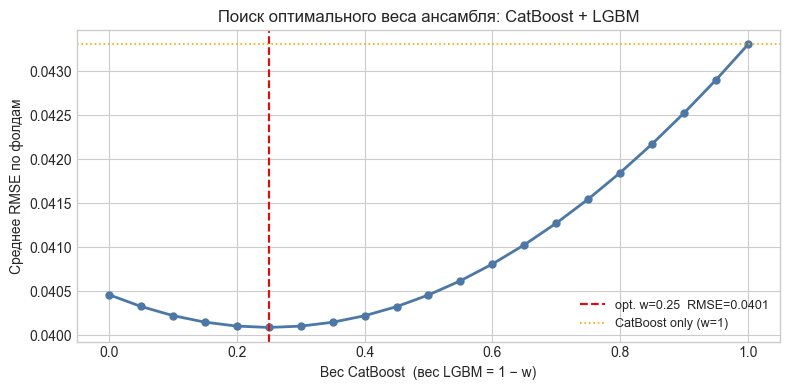


Ансамбль vs отдельные модели:


,model_name,RMSE_mean,RMSE_std,MAE_mean,OOS_R2_mean
2,Ensemble(CB×0.25+LGB×0.75),0.0382,0.0129,0.0288,0.1440
0,LGBMForecaster,0.0388,0.0121,0.0295,0.1219
1,CatBoostForecaster,0.0408,0.0153,0.0311,0.0356



CONFIG['models']['ensemble']['catboost_weight'] → 0.25


In [12]:
# ── 11.1 Загружаем предсказания CatBoost и LGBM ──────────────────────────────
cat_df  = load_all_folds("CatBoostForecaster")
lgbm_df = load_all_folds("LGBMForecaster")

# Строки должны быть выровнены по fold/region/year (одинаковый порядок)
merge_cols = ["fold", "region_id", "year"]
assert (cat_df[merge_cols].values == lgbm_df[merge_cols].values).all(), (
    "Порядок строк CatBoost и LGBM не совпадает — пересоздайте parquet через "
    "run_cross_validation(save_predictions=True)."
)

y_true  = cat_df["y_true"].values
y_bench = cat_df["y_bench"].values
y_cat   = cat_df["y_pred"].values
y_lgbm  = lgbm_df["y_pred"].values


# ── 11.2 Grid search по весу w (шаг 0.05) ────────────────────────────────────
weights   = np.arange(0.0, 1.01, 0.05)
rmse_by_w = [
    float(np.sqrt(np.mean((y_true - (w * y_cat + (1.0 - w) * y_lgbm)) ** 2)))
    for w in weights
]

best_idx  = int(np.argmin(rmse_by_w))
best_w    = float(weights[best_idx])
best_rmse = rmse_by_w[best_idx]

print(f"Оптимальный вес CatBoost: w = {best_w:.2f}")
print(f"  Ensemble RMSE (pooled) = {best_rmse:.4f}")
print(f"  CatBoost RMSE  (w=1.0) = {rmse_by_w[-1]:.4f}")
print(f"  LGBM RMSE      (w=0.0) = {rmse_by_w[0]:.4f}")

fig_wt = plot_ensemble_weight_search(weights, rmse_by_w, best_w)
fig_wt.savefig("figures/ensemble_weight_search.png", dpi=150, bbox_inches="tight")
plt.show()


# ── 11.3 Метрики ансамбля с оптимальным весом (по fold'ам) ───────────────────
y_ens_best = best_w * y_cat + (1.0 - best_w) * y_lgbm

records = []
for fold_id, grp_idx in cat_df.groupby("fold").groups.items():
    m = compute_metrics(y_true[grp_idx], y_ens_best[grp_idx], y_bench[grp_idx])
    records.append({
        "model_name": f"Ensemble(CB×{best_w:.2f}+LGB×{1-best_w:.2f})",
        "fold": fold_id, **m,
    })
ens_cv = pd.DataFrame(records)

ens_agg = (
    ens_cv.groupby("model_name")
    .agg(
        RMSE_mean=("RMSE", "mean"), RMSE_std=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),   MAE_std=("MAE", "std"),
        OOS_R2_mean=("OOS_R2", "mean"), OOS_R2_std=("OOS_R2", "std"),
    )
    .reset_index()
)

top3 = pd.concat([
    agg[agg["model_name"].isin(["CatBoostForecaster", "LGBMForecaster"])],
    ens_agg,
], ignore_index=True).sort_values("RMSE_mean")

print("\nАнсамбль vs отдельные модели:")
display(top3[["model_name", "RMSE_mean", "RMSE_std", "MAE_mean", "OOS_R2_mean"]].round(4))


# ── 11.4 Обновляем конфиг с найденным весом ──────────────────────────────────
CONFIG["models"]["ensemble"]["catboost_weight"] = best_w
print(f"\nCONFIG['models']['ensemble']['catboost_weight'] → {best_w:.2f}")

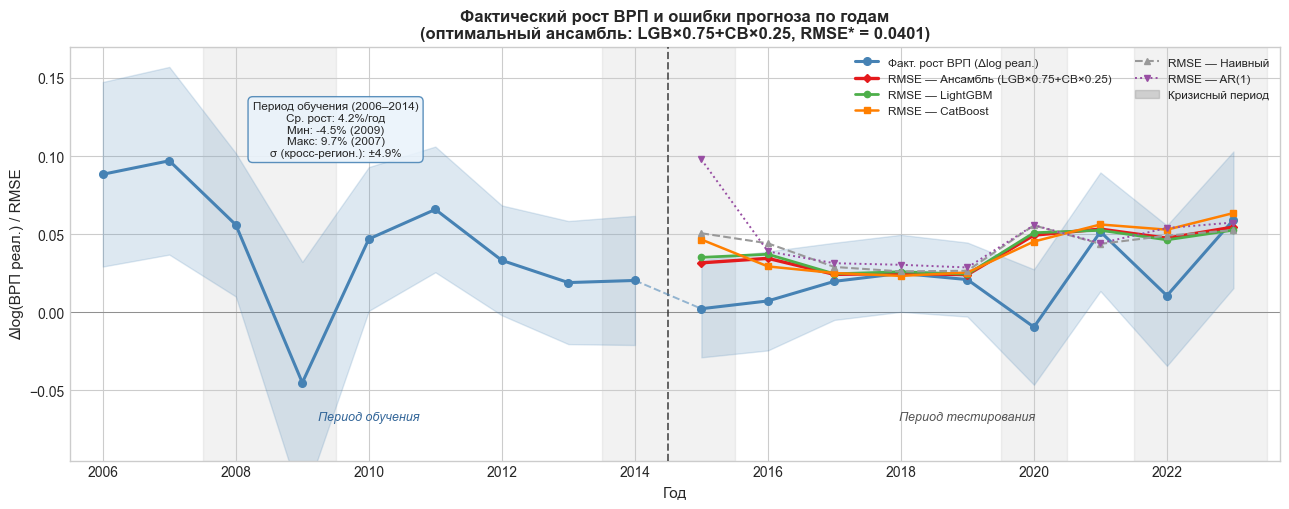

Оптимальный вес CB: 0.25  (RMSE=0.04009)


In [13]:
# ── 11.3 Комбинированный график: рост ВРП (обучение) + RMSE по годам (тест) ─────
# Оптимальный ансамбль: LGB×(1-best_w) + CB×best_w

import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

# Δlog(GRP_real) по годам из панели
panel_raw = pd.read_parquet(pred_dir / "panel.parquet")
pdf = panel_raw[['log_grp_real']].reset_index().sort_values(['region_id', 'year'])
pdf['grp_growth'] = pdf.groupby('region_id')['log_grp_real'].diff()
growth_yr = pdf.groupby('year')['grp_growth'].agg(['mean', 'std']).reset_index()
growth_yr = growth_yr[growth_yr.year.between(2006, 2023)]
train_g = growth_yr[growth_yr.year <= 2014]
test_g  = growth_yr[growth_yr.year >= 2015]

# RMSE по годам для каждой модели
def _rmse_yr(df):
    return df.groupby('year').apply(lambda g: np.sqrt(np.mean((g.y_true - g.y_pred)**2)))

model_specs = [
    ('LGBMForecaster',     'LightGBM',  '#4daf4a', 'o', 2.0, '-'),
    ('CatBoostForecaster', 'CatBoost',  '#ff7f00', 's', 1.8, '-'),
    ('NaiveForecaster',    'Наивный',   '#999999', '^', 1.5, '--'),
    ('AR1Forecaster',      'AR(1)',      '#984ea3', 'v', 1.4, ':'),
]
rmse_dict = {label: _rmse_yr(load_all_folds(fname)) for fname, label, *_ in model_specs}

# Оптимальный ансамбль с найденным best_w
cat_s = cat_df.sort_values(['year', 'region_id']).reset_index(drop=True)
lgb_s = lgbm_df.sort_values(['year', 'region_id']).reset_index(drop=True)
ens_df = cat_s.copy()
ens_df['y_pred'] = best_w * cat_s['y_pred'] + (1 - best_w) * lgb_s['y_pred']
ens_label = f'Ансамбль (LGB×{1-best_w:.2f}+CB×{best_w:.2f})'
rmse_dict[ens_label] = _rmse_yr(ens_df)

# ── Рисунок ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5.2))

crisis_bands = [(2008, 2009), (2014, 2015), (2020, 2020), (2022, 2023)]
for s, e in crisis_bands:
    ax.axvspan(s - 0.5, e + 0.5, alpha=0.10, color='gray', zorder=0)

ax.axvline(2014.5, color='#333333', lw=1.4, linestyle='--', alpha=0.75, zorder=3)
ax.axhline(0, color='black', lw=0.6, alpha=0.35, zorder=1)

# Левая часть: фактический рост ВРП (обучение)
ax.fill_between(train_g.year,
                train_g['mean'] - train_g['std'],
                train_g['mean'] + train_g['std'],
                alpha=0.18, color='steelblue', zorder=2)
ax.plot(train_g.year, train_g['mean'],
        color='steelblue', lw=2.2, marker='o', ms=5.5, zorder=4,
        label='Факт. рост ВРП (Δlog реал.)')

# Текстовый блок: характеристики обучающих данных
stats_text = (
    f"Период обучения (2006–2014)\n"
    f"Ср. рост: {train_g['mean'].mean()*100:.1f}%/год\n"
    f"Мин: {train_g['mean'].min()*100:.1f}% (2009)\n"
    f"Макс: {train_g['mean'].max()*100:.1f}% (2007)\n"
    f"σ (кросс-регион.): ±{train_g['std'].mean()*100:.1f}%"
)
ax.text(2009.5, 0.135, stats_text, ha='center', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#eaf3fb',
                  edgecolor='steelblue', alpha=0.88), zorder=6)

# Правая часть: RMSE моделей
plot_order = [ens_label, 'LightGBM', 'CatBoost', 'Наивный', 'AR(1)']
style_map = {
    ens_label:   ('#e41a1c', 'D', 2.4, '-'),
    'LightGBM':  ('#4daf4a', 'o', 2.0, '-'),
    'CatBoost':  ('#ff7f00', 's', 1.8, '-'),
    'Наивный':   ('#999999', '^', 1.5, '--'),
    'AR(1)':     ('#984ea3', 'v', 1.4, ':'),
}
for lbl in plot_order:
    if lbl not in rmse_dict:
        continue
    c, mk, lw, ls = style_map[lbl]
    ax.plot(rmse_dict[lbl].index, rmse_dict[lbl].values,
            color=c, lw=lw, ls=ls, marker=mk, ms=4.5, zorder=5,
            label=f'RMSE — {lbl}')

# Фактический рост ВРП (тест) — продолжение той же синей линии
ax.fill_between(test_g.year,
                test_g['mean'] - test_g['std'],
                test_g['mean'] + test_g['std'],
                alpha=0.18, color='steelblue', zorder=2)
ax.plot(test_g.year, test_g['mean'],
        color='steelblue', lw=2.2, marker='o', ms=5.5, zorder=4)
# Стыковка линий
ax.plot([2014, 2015],
        [train_g[train_g.year == 2014]['mean'].values[0],
         test_g[test_g.year == 2015]['mean'].values[0]],
        color='steelblue', lw=1.4, ls='--', alpha=0.55, zorder=4)

# Подписи периодов
ax.text(2010, -0.069, 'Период обучения', ha='center', fontsize=9,
        color='#336699', fontstyle='italic')
ax.text(2019, -0.069, 'Период тестирования', ha='center', fontsize=9,
        color='#555555', fontstyle='italic')

# Оформление
ax.set_xlim(2005.5, 2023.7)
ax.set_ylim(-0.095, 0.17)
ax.set_xlabel('Год', fontsize=11)
ax.set_ylabel('Δlog(ВРП реал.) / RMSE', fontsize=11)
ax.set_title(
    f'Фактический рост ВРП и ошибки прогноза по годам\n'
    f'(оптимальный ансамбль: LGB×{1-best_w:.2f}+CB×{best_w:.2f}, RMSE* = {min(rmse_by_w):.4f})',
    fontsize=12, fontweight='bold'
)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

handles, labels_leg = ax.get_legend_handles_labels()
crisis_patch = mpatches.Patch(color='gray', alpha=0.3, label='Кризисный период')
ax.legend(handles + [crisis_patch], labels_leg + ['Кризисный период'],
          ncol=2, fontsize=8.5, loc='upper right',
          framealpha=0.92, edgecolor='#cccccc')

fig.tight_layout()
fig.savefig('figures/rmse_and_growth_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Оптимальный вес CB: {best_w:.2f}  (RMSE={min(rmse_by_w):.5f})')


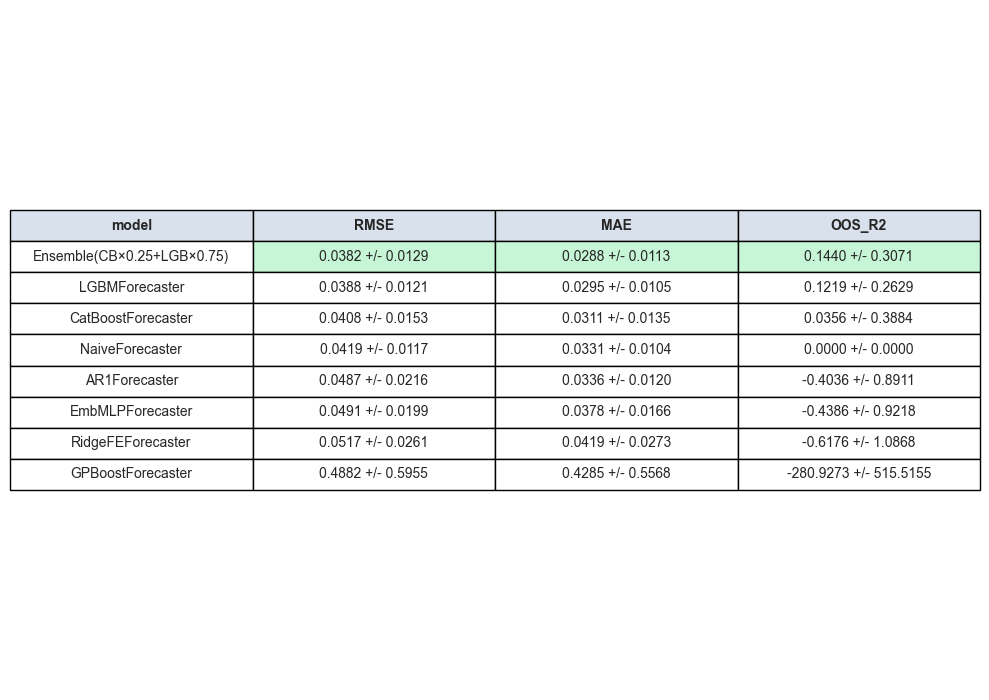

In [27]:
fig = plot_metrics_table(agg)
fig.savefig("figures/metrics_table.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Ablation study

Последовательное добавление групп признаков к лучшей ансамблевой модели:

| Сценарий | Признаки |
|----------|----------|
| A0 | LAG_BLOCK only (lag1, lag2, MA3, trend) |
| A1 | + PRODUCTION + INVESTMENT |
| A2 | + LABOUR + BUDGET |
| A3 | Все блоки (полная модель) |

Позволяет оценить предельный вклад каждой группы признаков в точность прогноза.

Лучшая древесная модель для ablation: LGBMForecaster


,RMSE,MAE,OOS_R2
scenario,,,
A0,0.0447,0.0356,-0.2153
A1,0.0431,0.0343,-0.1480
A2,0.0439,0.0350,-0.1871
A3,0.0442,0.0345,-0.1455


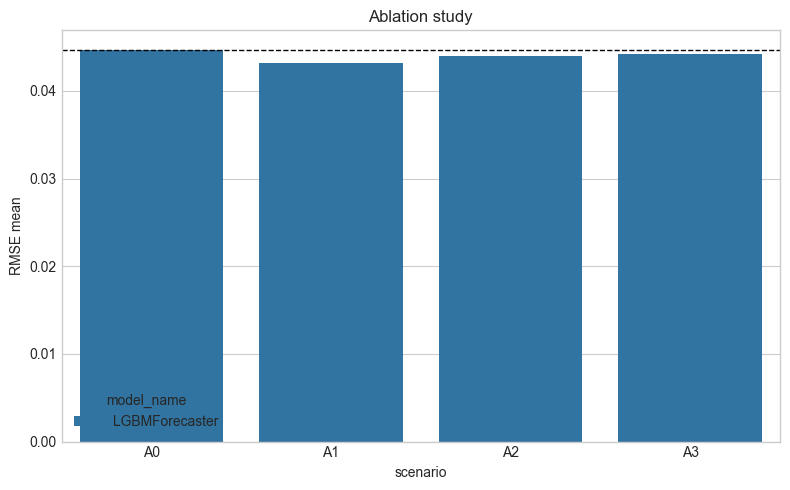

In [15]:
# Ablation проводится по лучшей одиночной древесной модели (не WeightedEnsemble,
# которому нельзя передать произвольный набор признаков без переинициализации).
tree_model_names = ["LGBMForecaster", "CatBoostForecaster", "GPBoostForecaster"]
best_name = agg[agg["model_name"].isin(tree_model_names)].iloc[0]["model_name"]
best_cls = {m.name: type(m) for m in models}[best_name]
print(f"Лучшая древесная модель для ablation: {best_name}")

feature_groups = {}
for fold in folds:
    for group, columns in fold.get("feature_groups", {}).items():
        feature_groups.setdefault(group, [])
        feature_groups[group].extend(columns)
feature_groups = {
    group: list(dict.fromkeys(columns))
    for group, columns in feature_groups.items()
}

_model_cfg_key = {
    "LGBMForecaster": "lgbm",
    "CatBoostForecaster": "catboost",
    "GPBoostForecaster": "gpboost",
}.get(best_name, "")
_model_cfg = dict(CONFIG["models"].get(_model_cfg_key, {}))
ablation_res = run_ablation_study(best_cls, folds, feature_groups, model_config=_model_cfg)
ablation_agg = ablation_res.groupby("scenario")[["RMSE", "MAE", "OOS_R2"]].mean().round(4)
display(ablation_agg)

fig = plot_ablation(ablation_res)
fig.savefig("figures/ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Robustness checks

**RC1 — исключение регионов-выбросов**: удаляются Москва, ХМАО, ЯНАО, Сахалинская обл.  
Проверяет, не обусловлены ли результаты несколькими крупными ресурсными регионами.

**RC2 — кризисные vs. нормальные годы**: тест-фолды разделяются на кризисные  
(2008–09, 2014–15, 2020, 2022–23) и остальные. Оценивается устойчивость качества прогноза  
в условиях экономических потрясений.

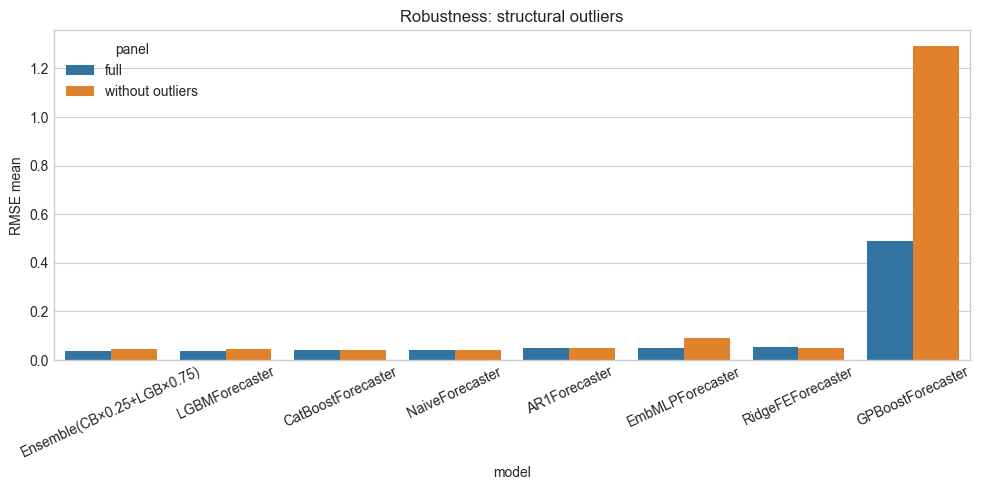

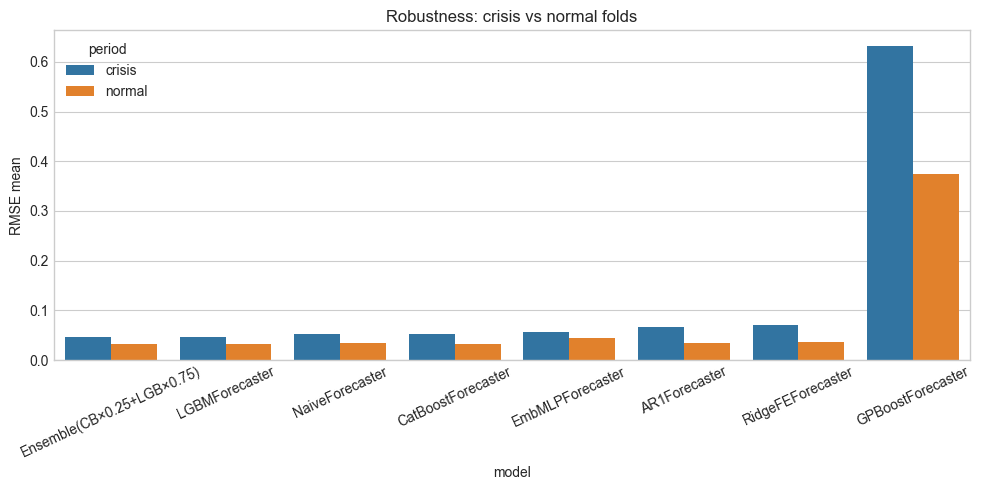

RC1 top-1: CatBoostForecaster
RC2 crisis top-1: Ensemble(CB×0.25+LGB×0.75)
RC2 normal top-1: CatBoostForecaster


In [16]:
rc1_results = robustness_check_outliers(
    models,
    folds,
    outlier_region_ids=CONFIG["robustness"]["outlier_region_ids"],
)
rc1_agg = aggregate_results(rc1_results)
fig = plot_robustness_outliers(agg, rc1_agg)
fig.savefig("figures/rc1_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

rc2_results = robustness_check_crisis(
    models,
    folds,
    crisis_years=CONFIG["robustness"]["crisis_years"],
)
fig = plot_robustness_crisis(rc2_results)
fig.savefig("figures/rc2_crisis.png", dpi=150, bbox_inches="tight")
plt.show()

print("RC1 top-1:", rc1_agg.iloc[0]["model_name"])
print("RC2 crisis top-1:", rc2_results["crisis"].iloc[0]["model_name"] if not rc2_results["crisis"].empty else "нет данных")
print("RC2 normal top-1:", rc2_results["normal"].iloc[0]["model_name"] if not rc2_results["normal"].empty else "нет данных")

## 6. SHAP-интерпретация

Применяется `shap.TreeExplainer` к лучшей **древесной** модели (LGBM / CatBoost / GPBoost).  
Если лучшая модель — `EmbMLPForecaster`, для интерпретации выбирается лучший среди деревьев.

Выходы:
- **Глобальная важность**: средний |SHAP| по всем наблюдениям
- **Beeswarm-plot**: распределение SHAP-значений для топ-N признаков
- **Group heatmap**: вклад блоков признаков по типу региона
- **Локальные примеры**: waterfall-объяснение для по одному региону каждого типа

In [17]:
X_test_all = pd.concat([fold["X_test"] for fold in folds], axis=0)
y_test_all = pd.concat([fold["y_test"] for fold in folds], axis=0)

predict_growth = CONFIG["validation"].get("predict_growth", False)
TREE_MODELS = {"LGBMForecaster", "CatBoostForecaster", "GPBoostForecaster"}
shap_model_name = best_name if best_name in TREE_MODELS else (
    agg[agg["model_name"].isin(TREE_MODELS)].iloc[0]["model_name"]
    if not agg[agg["model_name"].isin(TREE_MODELS)].empty else best_name
)
best_model_inst = [m for m in get_all_models(CONFIG["models"], predict_growth=predict_growth) if m.name == shap_model_name][0]
X_train_full = folds[-1]["X_train"]
y_train_full = folds[-1]["y_train"]
best_model_inst.fit(X_train_full, y_train_full)

region_meta_cols = [col for col in ["region_id", "region_type", "region_name"] if col in df.columns]
region_meta = df[region_meta_cols].drop_duplicates("region_id").copy()
if "region_type" not in region_meta.columns:
    region_meta["region_type"] = "unknown"
if "region_name" not in region_meta.columns:
    region_meta["region_name"] = region_meta["region_id"]

shap_dict = run_shap_analysis(best_model_inst, X_test_all, feature_groups, region_meta)


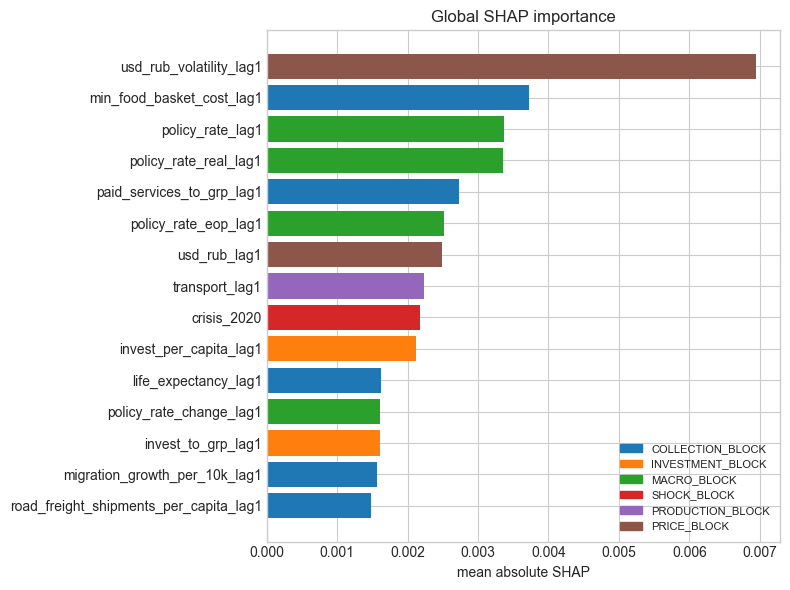

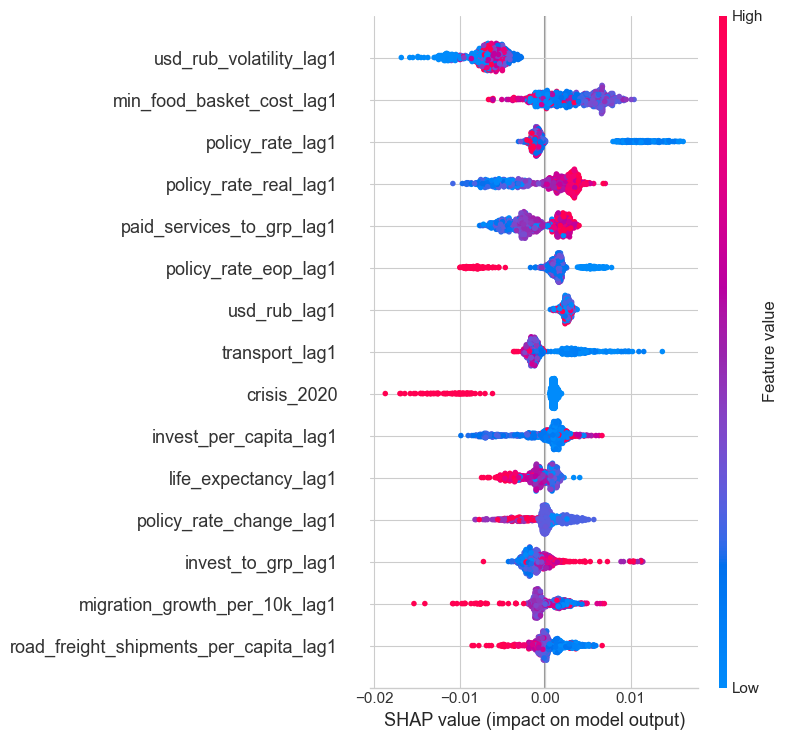

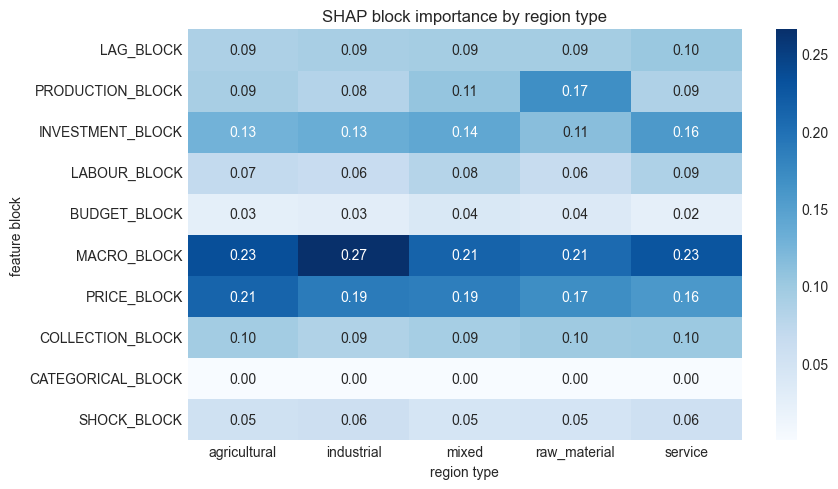

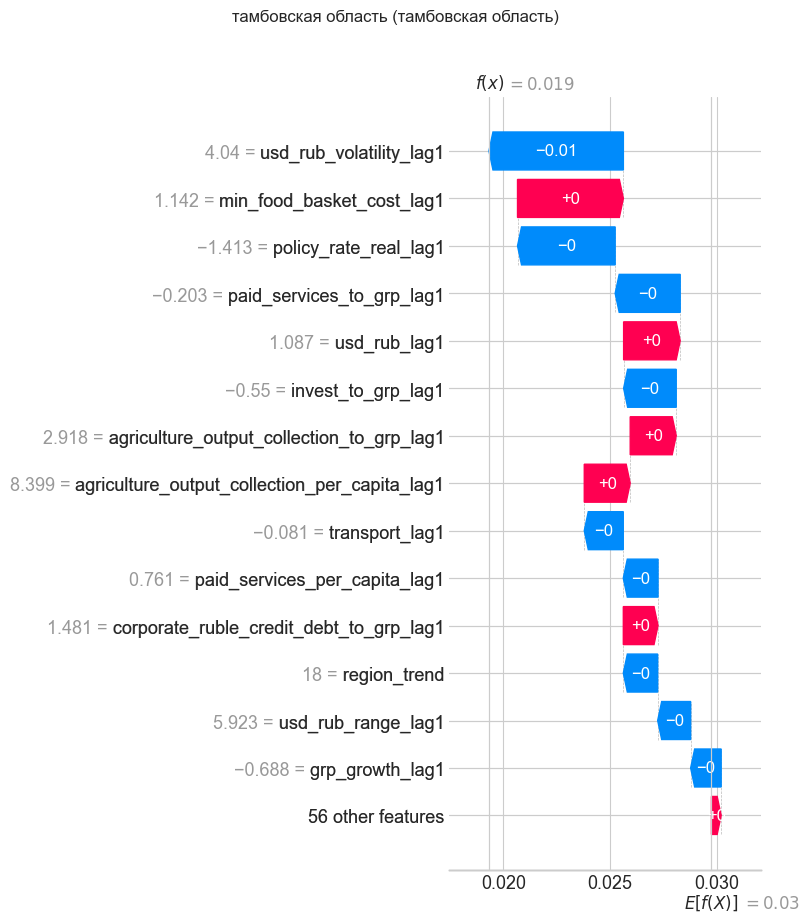

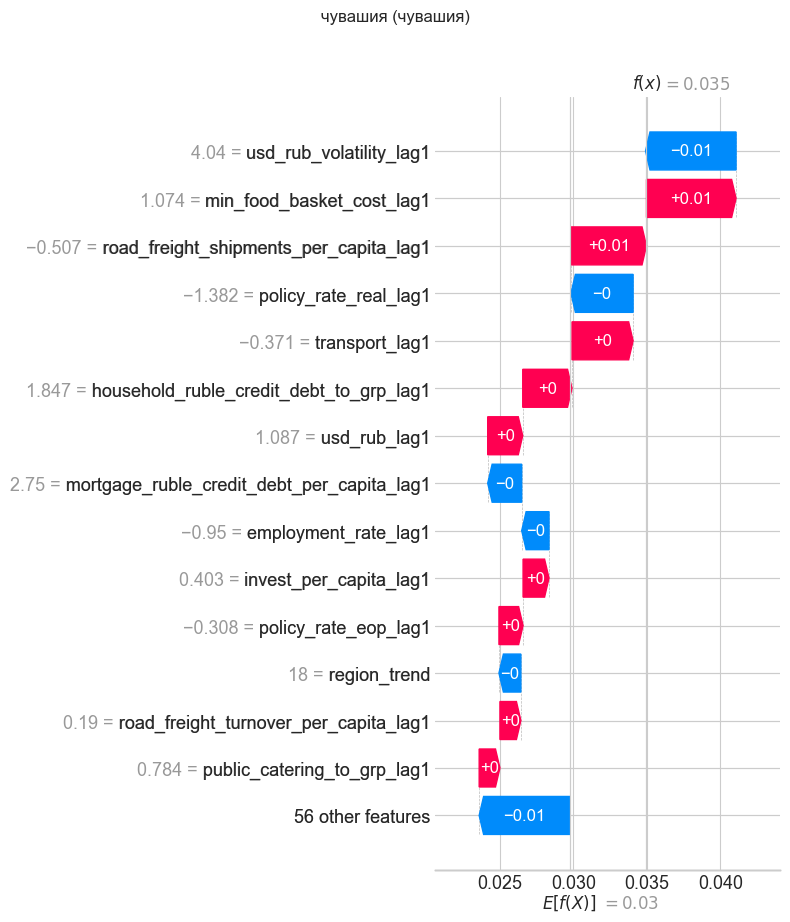

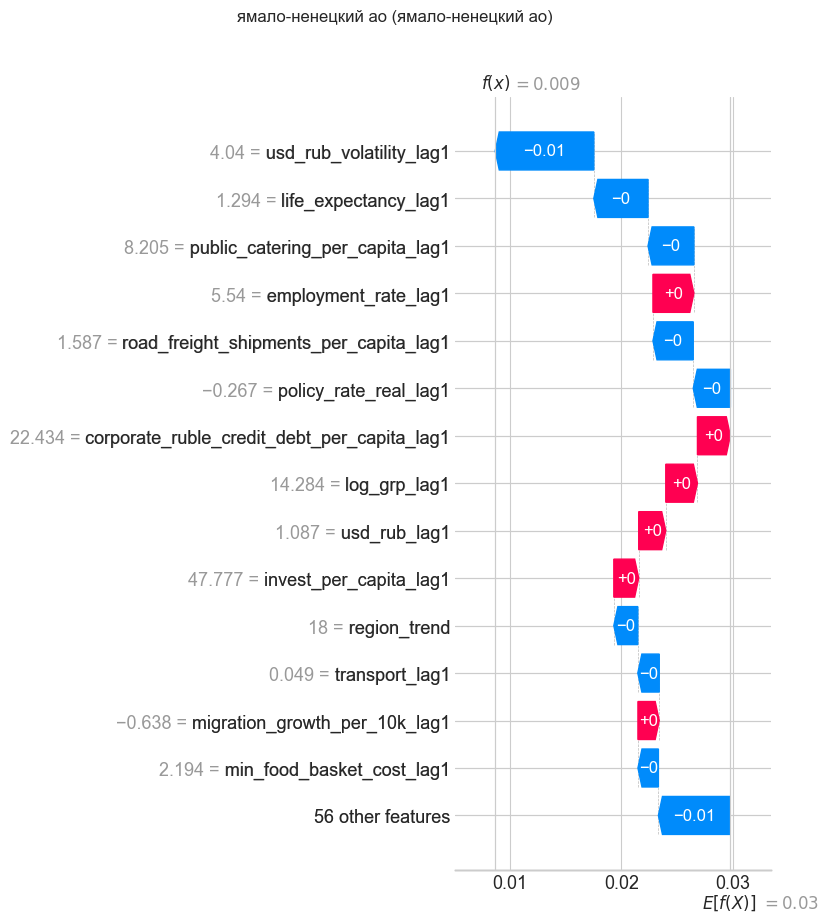

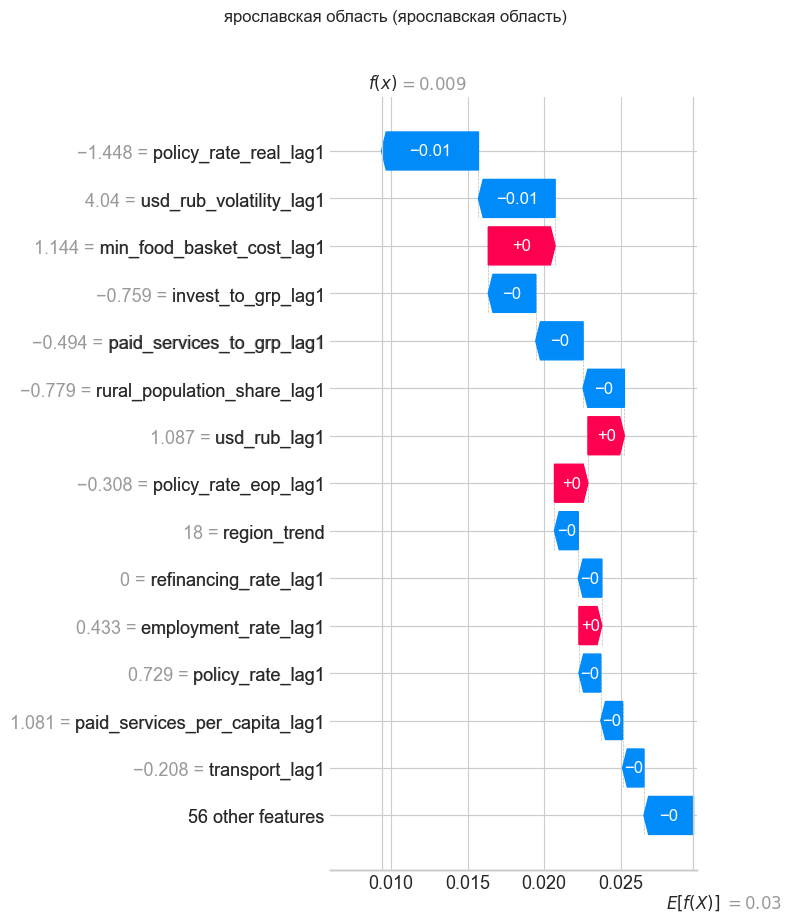

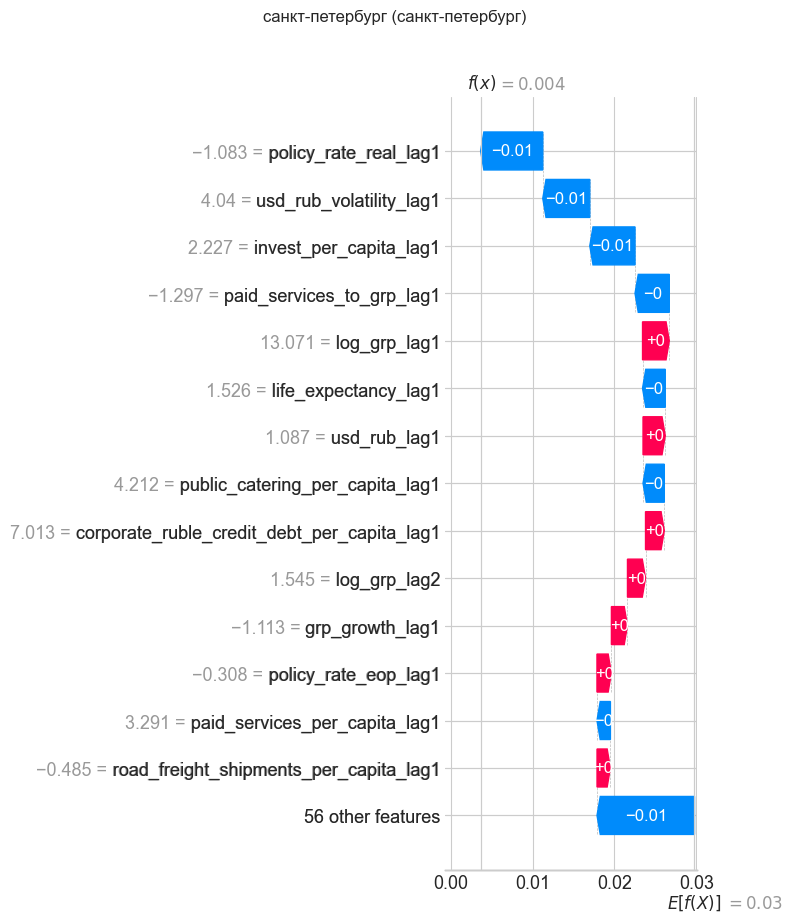

In [18]:
fig = plot_shap_global(shap_dict, top_n=CONFIG["shap"]["top_n_features"])
fig.savefig("figures/shap_global.png", dpi=150, bbox_inches="tight")
plt.show()

fig = plot_shap_beeswarm(shap_dict, top_n=CONFIG["shap"]["top_n_features"])
fig.savefig("figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

fig = plot_shap_group_heatmap(shap_dict)
fig.savefig("figures/shap_group_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

for ex_id, ex_name in shap_dict["local_examples"].items():
    fig = plot_shap_local(shap_dict, ex_id, ex_name)
    fig.savefig(f"figures/shap_local_{ex_id}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Анализ ошибок

Детальный разбор остатков лучшей модели по трём измерениям:

- **По регионам**: топ-20 регионов с наибольшим MAE — позволяет выявить систематически трудные субъекты
- **По годам**: динамика MAE всех моделей — видны кризисные всплески ошибок
- **Тепловая карта**: матрица ошибок регион × год для топ-30 регионов

In [19]:
cv_results

,model_name,fold,test_year,n_obs,RMSE,MAE,OOS_R2
0,NaiveForecaster,1,2015,85,0.050571,0.044360,0.000000e+00
1,AR1Forecaster,1,2015,85,0.097798,0.050329,-2.739887e+00
2,RidgeFEForecaster,1,2015,85,0.089970,0.084780,-2.165178e+00
3,LGBMForecaster,1,2015,85,0.035115,0.028809,5.178534e-01
4,CatBoostForecaster,1,2015,85,0.046545,0.036227,1.528706e-01
...,...,...,...,...,...,...,...
67,LGBMForecaster,9,2023,85,0.052595,0.040974,-7.096432e-10
68,CatBoostForecaster,9,2023,85,0.063502,0.051805,-4.577679e-01
69,Ensemble(CB×0.25+LGB×0.75),9,2023,85,0.054565,0.043336,-7.634439e-02
70,GPBoostForecaster,9,2023,85,0.268696,0.215070,-2.509990e+01


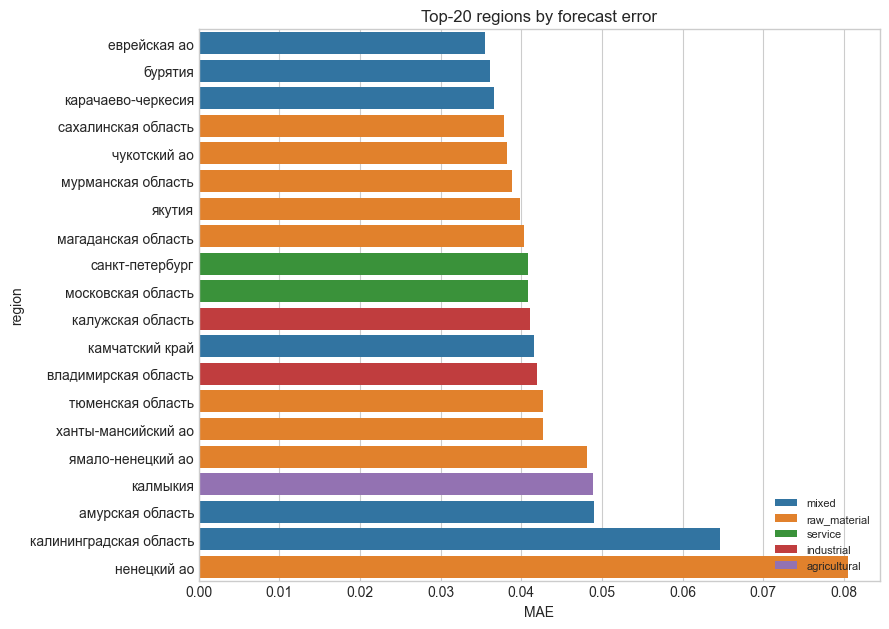

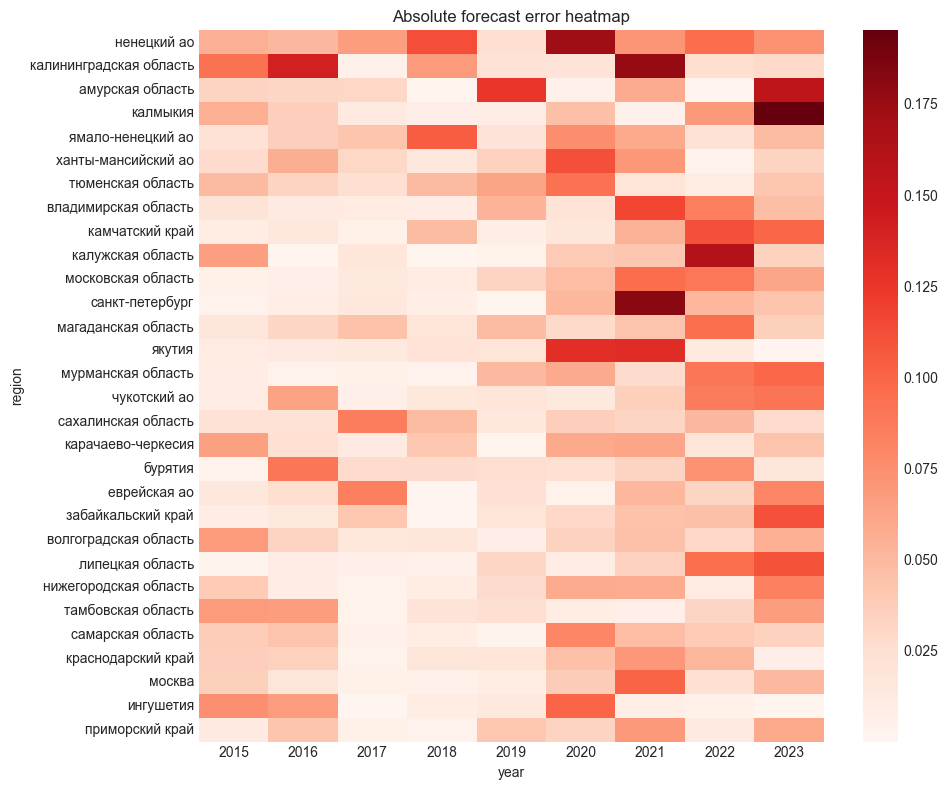

In [20]:
err = error_analysis(cv_results, predictions_dir=CONFIG["data"]["processed_dir"])

fig = plot_error_by_region(err, top_n=20)
fig.savefig("figures/error_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

fig = plot_error_heatmap(err)
fig.savefig("figures/error_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Итоговые выводы

Сводка результатов: лучшая модель, улучшение над наивным бенчмарком (OOS R² и RMSE),  
топ-5 наиболее значимых признаков по SHAP.  

**Критерий победы над бенчмарком**: OOS R² > 0 (хотя бы на части фолдов) и RMSE ниже наивного прогноза.

In [21]:
best_rmse = agg.iloc[0]
naive_rmse = agg[agg["model_name"] == "NaiveForecaster"]["RMSE_mean"].values[0]
improvement_pct = (naive_rmse - best_rmse["RMSE_mean"]) / naive_rmse * 100

top_features = "\n".join(
    f"  {idx + 1}. {feature}"
    for idx, feature in enumerate(shap_dict["global_importance"].head(5).index)
)

print(f"""
=== ИТОГОВЫЙ ВЫВОД ===
Лучшая модель: {best_rmse['model_name']}
RMSE (mean over folds): {best_rmse['RMSE_mean']:.4f}
MAE  (mean over folds): {best_rmse['MAE_mean']:.4f}
OOS R2 (mean):          {best_rmse['OOS_R2_mean']:.4f}

Улучшение RMSE vs. наивного прогноза: {improvement_pct:.1f}%

Наиболее важные признаки (топ-5 по SHAP):
{top_features}
""")


=== ИТОГОВЫЙ ВЫВОД ===
Лучшая модель: Ensemble(CB×0.25+LGB×0.75)
RMSE (mean over folds): 0.0382
MAE  (mean over folds): 0.0288
OOS R2 (mean):          0.1440

Улучшение RMSE vs. наивного прогноза: 8.9%

Наиболее важные признаки (топ-5 по SHAP):
  1. usd_rub_volatility_lag1
  2. min_food_basket_cost_lag1
  3. policy_rate_lag1
  4. policy_rate_real_lag1
  5. paid_services_to_grp_lag1



## 9. EmbMLP: нейросеть с эмбеддингами регионов

`EmbMLPForecaster` кодирует `region_id`, `region_type` и `federal_district`  
через обучаемые эмбеддинги размерности 8, 2, 2 соответственно;  
объединяет их с числовыми признаками и прогоняет через двухслойный MLP  
с BatchNorm, ReLU и Dropout.  
Модель отключена в основном запуске — здесь запускается отдельно  
с уменьшенным числом трайлов (20) для обеспечения разумного времени обучения.

In [22]:
# Включаем EmbMLP и строим экземпляр с параметрами из конфига
emb_cfg = copy.deepcopy(CONFIG["models"].get("emb_mlp", {}))
emb_cfg.pop("enabled", None)          # убираем флаг — он не нужен конструктору

emb_model = EmbMLPForecaster(**emb_cfg) if emb_cfg else EmbMLPForecaster()
print("EmbMLPForecaster параметры:", emb_model.params)

emb_cv = run_cross_validation(
    models=[emb_model],
    folds=folds,
    tune=True,
    n_trials=50,                       # меньше трайлов для скорости
    save_predictions=False,
    clean_output=True,
)

emb_agg = aggregate_results(emb_cv)
display(emb_agg.round(4))

# Сравниваем с основной таблицей
compare_df = pd.concat([agg, emb_agg], ignore_index=True).drop_duplicates("model_name")
compare_df = compare_df.sort_values("RMSE_mean").reset_index(drop=True)
print("\nСводная таблица (с EmbMLP):")
display(compare_df[["model_name", "RMSE_mean", "MAE_mean", "OOS_R2_mean"]].round(4))

EmbMLPForecaster параметры: {'hidden_sizes': [32, 16], 'dropout': 0.2, 'lr': 0.001, 'max_epochs': 200, 'batch_size': 256, 'patience': 15, 'weight_decay': 0.0001, 'num_threads': 1, 'random_state': 42}


EmbMLPForecaster | fold 9: 100%|██████████| 9/9 [02:15<00:00, 15.02s/it, best=EmbMLPForecaster fold=4 RMSE=0.0266]

Best single fold: EmbMLPForecaster | fold=4 | test_year=2018 | RMSE=0.0266 | MAE=0.0185 | OOS_R2=-0.0396


,model_name,RMSE_mean,RMSE_std,MAE_mean,MAE_std,OOS_R2_mean,OOS_R2_std
0,EmbMLPForecaster,0.0485,0.0188,0.037,0.0149,-0.388,0.7829



Сводная таблица (с EmbMLP):


,model_name,RMSE_mean,MAE_mean,OOS_R2_mean
0,Ensemble(CB×0.25+LGB×0.75),0.0382,0.0288,0.1440
1,LGBMForecaster,0.0388,0.0295,0.1219
2,CatBoostForecaster,0.0408,0.0311,0.0356
3,NaiveForecaster,0.0419,0.0331,0.0000
4,AR1Forecaster,0.0487,0.0336,-0.4036
5,EmbMLPForecaster,0.0491,0.0378,-0.4386
6,RidgeFEForecaster,0.0517,0.0419,-0.6176
7,GPBoostForecaster,0.4882,0.4285,-280.9273


## 10. Диагностика GPBoost: GP-компонента включена

В основном запуске GP-компонента при прогнозировании отключена  
(`ignore_gp_model=True`) из-за нестабильности условных предсказаний  
случайных эффектов для новых временных периодов.  
Здесь тестируется вариант с включённой GP-компонентой —  
чтобы оценить, насколько она меняет качество прогноза.

In [23]:
class GPBoostWithGP(GPBoostForecaster):
    """GPBoost с включённой GP-компонентой при OOS-прогнозировании.

    В отличие от базового GPBoostForecaster (который использует только
    fixed-effects через ignore_gp_model=True), этот вариант сначала пробует
    GP-прогноз с group_data_pred, и только при исключении откатывается
    к fixed-effects.

    Предсказания клиппируются в ±3σ тренировочного y, чтобы предотвратить
    катастрофические выбросы при экстраполяции ковариационной матрицы GP
    на новые временны́е периоды.
    """
    name = "GPBoostWithGP"

    def predict(self, X_test: pd.DataFrame) -> np.ndarray:
        if self.booster_ is None or self.gp_model_ is None:
            raise RuntimeError("GPBoostWithGP не обучена.")
        X_pred = _transform_numeric_preprocessor(X_test, self.preprocessor_)
        group_data_pred = X_test[self.group_col].astype(str).to_numpy()
        try:
            pred = self.booster_.predict(
                data=X_pred,
                group_data_pred=group_data_pred,
                predict_var=False,
            )
            raw = self._extract_pred_mean(pred)
            # Клиппируем в ±3σ, чтобы GP-экстраполяция не вызывала взрыва ошибки
            clip_bound = 3.0 * self.train_std_
            clipped = np.clip(raw, -clip_bound, clip_bound)
            n_clipped = int(np.sum(np.abs(raw) > clip_bound))
            if n_clipped:
                print(
                    f"  [GPBoostWithGP] GP clipped {n_clipped}/{len(raw)} predictions "
                    f"beyond ±{clip_bound:.3f} (3σ train_std)"
                )
            return clipped
        except Exception as exc:
            print(
                f"  [GPBoostWithGP] GP predict failed "
                f"({type(exc).__name__}), falling back to fixed-effects"
            )
            pred = self.booster_.predict(data=X_pred, ignore_gp_model=True)
            return self._extract_pred_mean(pred)


gpboost_cfg = dict(CONFIG["models"].get("gpboost", {}))
gpboost_gp = GPBoostWithGP(**gpboost_cfg)

gpboost_cv = run_cross_validation(
    models=[gpboost_gp],
    folds=folds,
    tune=True,
    n_trials=20,
    save_predictions=False,
    clean_output=True,
)
gpboost_gp_agg = aggregate_results(gpboost_cv)

# Сравниваем оба варианта GPBoost
gpboost_base = agg[agg["model_name"] == "GPBoostForecaster"]
comparison = pd.concat([gpboost_base, gpboost_gp_agg], ignore_index=True)
print("Сравнение GPBoost (без GP) vs GPBoostWithGP (с GP):")
display(comparison[["model_name", "RMSE_mean", "RMSE_std", "OOS_R2_mean", "OOS_R2_std"]].round(4))


GPBoostWithGP | fold 9: 100%|██████████| 9/9 [00:45<00:00,  5.04s/it, best=GPBoostWithGP fold=5 RMSE=0.1164]

Best single fold: GPBoostWithGP | fold=5 | test_year=2019 | RMSE=0.1164 | MAE=0.0996 | OOS_R2=-18.2237
Сравнение GPBoost (без GP) vs GPBoostWithGP (с GP):


,model_name,RMSE_mean,RMSE_std,OOS_R2_mean,OOS_R2_std
0,GPBoostForecaster,0.4882,0.5955,-280.9273,515.5155
1,GPBoostWithGP,0.1678,0.0361,-19.6125,16.5109


In [24]:
gpboost_gp_agg

,model_name,RMSE_mean,RMSE_std,MAE_mean,MAE_std,OOS_R2_mean,OOS_R2_std
0,GPBoostWithGP,0.167834,0.036121,0.15615,0.042188,-19.612533,16.510886


## 12. Тест Дибольда–Мариано (DM)

Проверяем статистическую значимость превосходства CatBoost над наивным  
прогнозом. Статистика теста:

$$DM = \frac{\bar{d}}{\widehat{\mathrm{SE}}(\bar{d})}, \quad
d_t = L(e_{1t}) - L(e_{2t}), \quad
L(e) = e^2$$

При нулевой гипотезе об одинаковом качестве прогнозов $DM \sim N(0,1)$  
(двустороннее), что даёт p-value для проверки улучшения.  
Дополнительно тестируем LightGBM vs Naive.

In [25]:
from scipy import stats


def diebold_mariano(e1: np.ndarray, e2: np.ndarray, loss: str = "squared") -> dict:
    """
    Тест Дибольда–Мариано: проверяет, даёт ли модель 2 меньшие потери, чем модель 1.

    d_t = L(e1_t) - L(e2_t),  где e1 — ошибки модели 1, e2 — модели 2.
    d_bar > 0  ⟹  потери модели 1 больше  ⟹  модель 2 точнее.
    H0: d_bar = 0 (равное качество).
    H1: d_bar > 0 (модель 2 лучше) — одностороннее.

    loss: 'squared' (MSE-потери) или 'absolute' (MAE-потери).
    """
    if loss == "squared":
        d = e1 ** 2 - e2 ** 2
    else:
        d = np.abs(e1) - np.abs(e2)

    d_bar = d.mean()
    T = len(d)
    gamma0 = np.var(d, ddof=1)
    dm_stat = d_bar / np.sqrt(gamma0 / T)
    p_two = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    # H1: d_bar > 0 → DM > 0 → p_one = P(Z > DM | H0) = 1 − Φ(DM)
    p_one = 1 - stats.norm.cdf(dm_stat)
    return {"d_bar": d_bar, "DM": dm_stat, "p_two": p_two, "p_one": p_one, "T": T}


# cat_df и lgbm_df загружены в секции 11; здесь нужен только Naive.
naive_df = load_all_folds("NaiveForecaster")

key = ["fold", "region_id", "year"]
merged_cat  = cat_df.set_index(key).join(
    naive_df.set_index(key)[["y_pred"]], rsuffix="_naive"
).reset_index()
merged_lgbm = lgbm_df.set_index(key).join(
    naive_df.set_index(key)[["y_pred"]], rsuffix="_naive"
).reset_index()

e_naive_cat  = (merged_cat["y_true"]  - merged_cat["y_pred_naive"]).values
e_cat        = (merged_cat["y_true"]  - merged_cat["y_pred"]).values
e_naive_lgbm = (merged_lgbm["y_true"] - merged_lgbm["y_pred_naive"]).values
e_lgbm       = (merged_lgbm["y_true"] - merged_lgbm["y_pred"]).values

res_cat  = diebold_mariano(e_naive_cat, e_cat,  loss="squared")
res_lgbm = diebold_mariano(e_naive_lgbm, e_lgbm, loss="squared")

dm_table = pd.DataFrame([
    {"Сравнение": "CatBoost vs Naive", **res_cat},
    {"Сравнение": "LightGBM vs Naive", **res_lgbm},
]).set_index("Сравнение")

print("Тест Дибольда–Мариано:")
print("  d_bar > 0  ⟹  e1² > e2²  ⟹  вторая модель точнее наивного")
print("  p_one = P(DM > наблюдаемое | H0): мало → отвергаем H0 в пользу H1")
display(dm_table.round(4))

for label, res in [("CatBoost vs Naive", res_cat), ("LightGBM vs Naive", res_lgbm)]:
    direction = "лучше наивного" if res["d_bar"] > 0 else "хуже наивного"
    sig = "значимо (p < 0.05)" if res["p_one"] < 0.05 else "не значимо (p ≥ 0.05)"
    print(f"{label}: {direction}, {sig}  "
          f"(d_bar={res['d_bar']:+.6f}, DM={res['DM']:.3f}, one-sided p={res['p_one']:.4f})")

Тест Дибольда–Мариано:
  d_bar > 0  ⟹  e1² > e2²  ⟹  вторая модель точнее наивного
  p_one = P(DM > наблюдаемое | H0): мало → отвергаем H0 в пользу H1


,d_bar,DM,p_two,p_one,T
Сравнение,,,,,
CatBoost vs Naive,0.0000,0.0456,0.9636,0.4818,765
LightGBM vs Naive,0.0002,6.2474,0.0000,0.0000,765


CatBoost vs Naive: лучше наивного, не значимо (p ≥ 0.05)  (d_bar=+0.000004, DM=0.046, one-sided p=0.4818)
LightGBM vs Naive: лучше наивного, значимо (p < 0.05)  (d_bar=+0.000242, DM=6.247, one-sided p=0.0000)


## 13. Метрики в рублях (обратное преобразование из лог-пространства)

Преобразуем предсказания темпа роста обратно в уровень ВРП:  
$$\widehat{\text{ВРП}}_t = \exp(\log\text{ВРП}_{t-1} + \hat{y}_t)$$

Метрики в рублях: **RMSE**, **MAE** (млрд руб.) и **MAPE** (%).  
MAPE = `mean |ВРП_pred − ВРП_true| / ВРП_true × 100%` и примерно равна
`exp(MAE_log) − 1` (для симметричных распределений).


lag_lookup: 1500 записей, регионы 85, годы 2006–2023
Метрики прогноза ВРП в рублёвом масштабе:


,model,RMSE_bln_rub,MAE_bln_rub,MAPE_pct
0,CatBoostForecaster,18.87,6.28,3.08
1,Ensemble(CB×0.25+LGB×0.75),19.04,6.24,2.88
2,LGBMForecaster,20.05,6.57,2.95
3,NaiveForecaster,21.30,7.29,3.34
4,RidgeFEForecaster,27.60,8.69,4.09
5,EmbMLPForecaster,28.65,8.23,3.74
6,AR1Forecaster,36.33,8.44,3.45
7,GPBoostForecaster,134.63,56.01,36.40


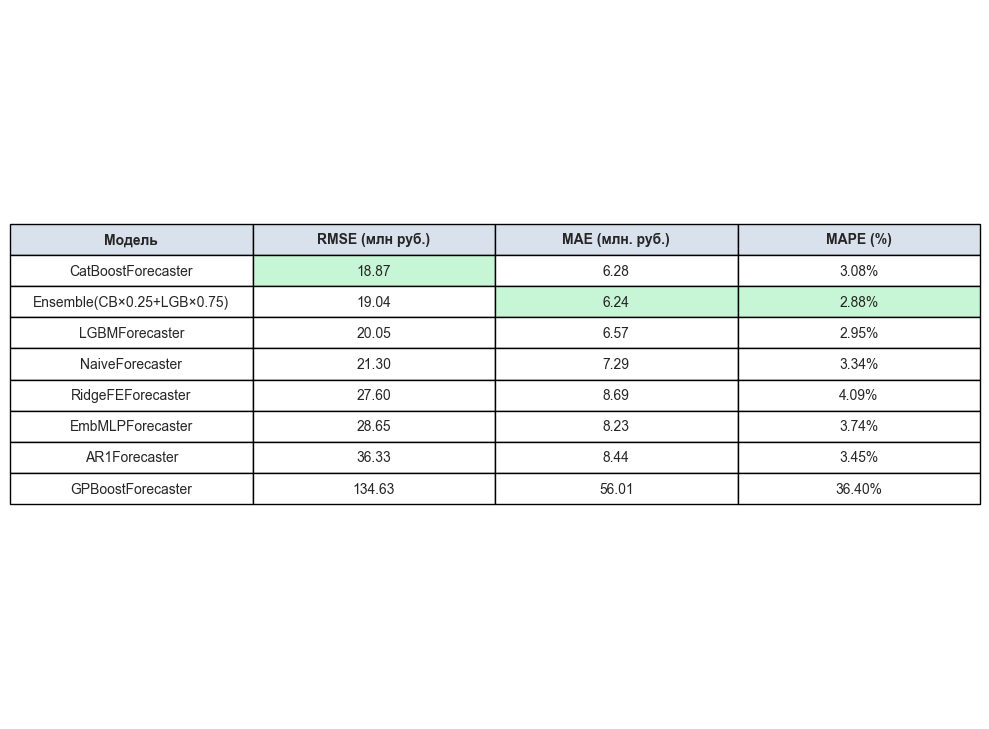

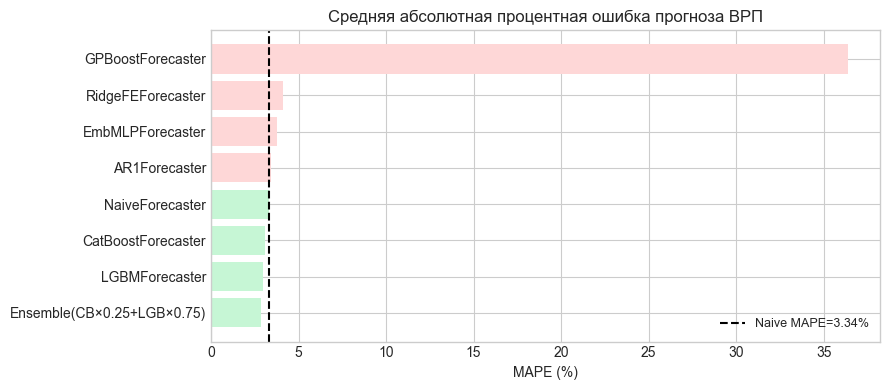

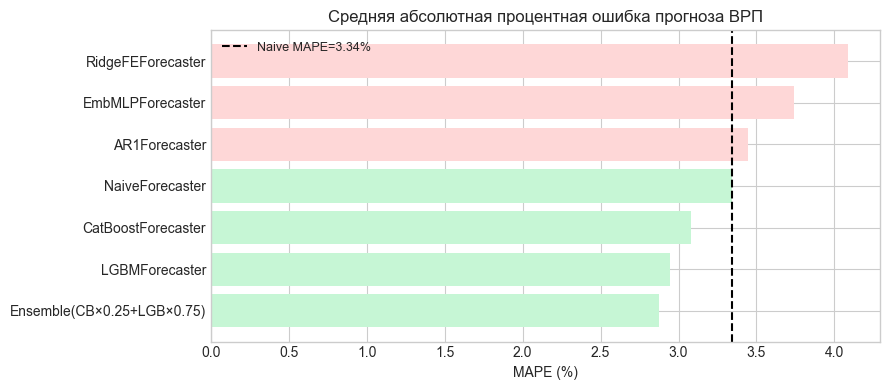

In [26]:
# Требует: секция 11 должна быть выполнена (нужны cat_df, lgbm_df, best_w).

# ── 13.1 Загружаем panel и вычисляем log_grp_lag1 ────────────────────────────
# log_grp_lag1 — производный признак FeatureBuilder (lag от log_grp_real).
# В сырой panel.parquet его нет → вычисляем через groupby + shift(1).
panel = pd.read_parquet(pred_dir / "panel.parquet")
panel.reset_index(drop=True, inplace=True)
panel["region_id"] = panel["region_id"].astype(str)
panel["year"]      = panel["year"].astype(int)
panel = panel.sort_values(["region_id", "year"])

if "log_grp_lag1" not in panel.columns:
    panel["log_grp_lag1"] = panel.groupby("region_id")["log_grp_real"].shift(1)

lag_lookup = (
    panel[["region_id", "year", "log_grp_lag1"]]
    .dropna(subset=["log_grp_lag1"])
    .set_index(["region_id", "year"])["log_grp_lag1"]
)
print(f"lag_lookup: {len(lag_lookup)} записей, "
      f"регионы {lag_lookup.index.get_level_values('region_id').nunique()}, "
      f"годы {lag_lookup.index.get_level_values('year').min()}–"
      f"{lag_lookup.index.get_level_values('year').max()}")


# ── 13.2 Вычисляем метрики для каждой базовой модели ─────────────────────────
MODEL_NAMES = [
    "CatBoostForecaster", "LGBMForecaster", "NaiveForecaster",
    "AR1Forecaster", "EmbMLPForecaster", "RidgeFEForecaster",
    "GPBoostForecaster",
]

ruble_rows = []
for model_name in MODEL_NAMES:
    files = sorted(pred_dir.glob(f"predictions_{model_name}_fold*.parquet"))
    if not files:
        continue
    df_m = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    df_m["region_id"] = df_m["region_id"].astype(str)
    df_m["year"]      = df_m["year"].astype(int)

    # Берём log_grp_lag1 из parquet (если есть) или из panel по ключу
    if "log_grp_lag1" in df_m.columns and df_m["log_grp_lag1"].notna().mean() > 0.5:
        lag_col = df_m["log_grp_lag1"]
    else:
        lag_col = pd.Series(
            df_m.set_index(["region_id", "year"]).index.map(lag_lookup).values,
            index=df_m.index,
        )

    df_m = df_m.copy()
    df_m["_lag"] = lag_col
    valid = df_m.dropna(subset=["_lag"])
    if valid.empty:
        print(f"[WARNING] {model_name}: нет log_grp_lag1 — пропущено")
        continue

    # ВРП в миллионах руб. → делим на 1 000 для перевода в млрд руб.
    grp_true = np.exp(valid["_lag"] + valid["y_true"])
    grp_pred = np.exp(valid["_lag"] + valid["y_pred"])
    err = grp_true - grp_pred

    ruble_rows.append({
        "model": model_name,
        "RMSE_bln_rub": float(np.sqrt(np.mean(err ** 2))) / 1_000,
        "MAE_bln_rub":  float(np.mean(np.abs(err))) / 1_000,
        "MAPE_pct":     float(np.mean(np.abs(err / grp_true))) * 100,
    })


# ── 13.3 Добавляем пост-CV ансамбль с оптимальным весом ──────────────────────
try:
    _lag_ens = cat_df.copy()
    _lag_ens["region_id"] = _lag_ens["region_id"].astype(str)
    _lag_ens["year"]      = _lag_ens["year"].astype(int)
    if "log_grp_lag1" in cat_df.columns:
        _lag_ens["_lag"] = cat_df["log_grp_lag1"].values
    else:
        _lag_ens["_lag"] = pd.Series(
            _lag_ens.set_index(["region_id", "year"]).index.map(lag_lookup).values,
            index=_lag_ens.index,
        )
    _lag_ens = _lag_ens.dropna(subset=["_lag"])
    _y_ens = (best_w * _lag_ens["y_pred"].values
              + (1 - best_w) * lgbm_df.loc[_lag_ens.index, "y_pred"].values)
    _gt = np.exp(_lag_ens["_lag"] + _lag_ens["y_true"].values)
    _gp = np.exp(_lag_ens["_lag"] + _y_ens)
    _err = _gt - _gp
    ruble_rows.append({
        "model": f"Ensemble(CB×{best_w:.2f}+LGB×{1-best_w:.2f})",
        "RMSE_bln_rub": float(np.sqrt(np.mean(_err ** 2))) / 1_000,
        "MAE_bln_rub":  float(np.mean(np.abs(_err))) / 1_000,
        "MAPE_pct":     float(np.mean(np.abs(_err / _gt))) * 100,
    })
except Exception as e:
    print(f"[INFO] Ансамбль в рублях пропущен: {e}")

ruble_metrics = (
    pd.DataFrame(ruble_rows)
    .sort_values("RMSE_bln_rub")
    .reset_index(drop=True)
)

print("Метрики прогноза ВРП в рублёвом масштабе:")
display(ruble_metrics.round(2))


# ── 13.4 Визуализация ────────────────────────────────────────────────────────
fig_rub = plot_ruble_metrics_table(ruble_metrics)
fig_rub.savefig("figures/ruble_metrics_table.png", dpi=150, bbox_inches="tight")
plt.show()

fig_mape = plot_mape_by_model(ruble_metrics)
fig_mape.savefig("figures/mape_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

fig_mape = plot_mape_by_model(ruble_metrics.iloc[:-1, :])
fig_mape.savefig("figures/mape_by_model.png", dpi=150, bbox_inches="tight")
plt.show()